In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
tqdm.pandas()
pd.set_option("display.max_columns", None)

# Student_log

In [3]:
path = '.\\Data_Verified\\'
student_log = pd.read_csv(f"{path}Student_log.csv")


## Verify dates 18th Feb 2018 to 30th June 2019

In [10]:
print(student_log['timecreated'].min())
print(student_log['timecreated'].max())
#ok


2019-02-18 00:00:02
2019-06-29 23:59:08


## Verify missing values

In [120]:
student_log.isna().sum()

component      0
action         0
target         0
userid         0
courseid       0
timecreated    0
dtype: int64

## Verify data type

In [122]:
student_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12139424 entries, 0 to 12139423
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   component    object        
 1   action       object        
 2   target       object        
 3   userid       int64         
 4   courseid     int64         
 5   timecreated  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 555.7+ MB


## Verify unique items 

In [123]:
student_log.nunique()

component           36
action              37
target              74
userid           16128
courseid          2826
timecreated    6040037
dtype: int64

## Verify figure -component

Bbox([[25.36432671440971, -178.35277777777776], [576.0, 422.40000000000003]])

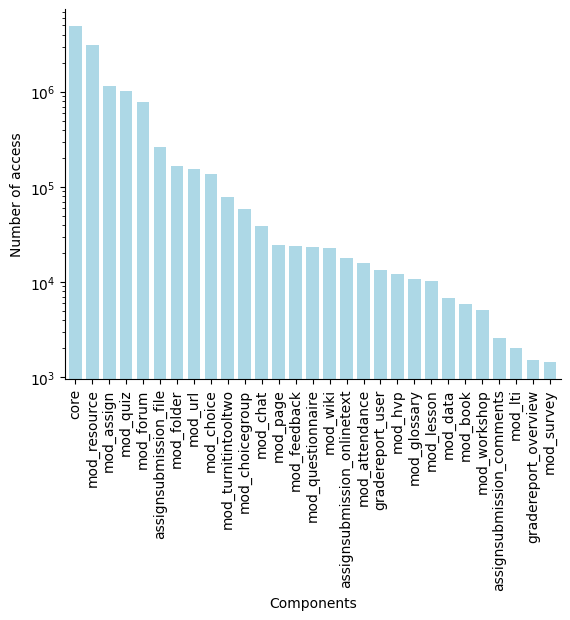

In [124]:
x = student_log['component'].value_counts()
ax = x[x>1000].plot(kind='bar',color='lightblue', width=0.75, align='center',logy=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Components')
ax.set_ylabel('Number of access')
yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5)
yticklabels = yticks    
ax.get_tightbbox()


# Student_grade_detailed

## Publish- Student_grade_detailed.csv

In [73]:
student_grade_detailed = pd.read_csv(f"{path}Student_grade_detailed.csv")



## Verify unique items

In [109]:
student_grade_detailed.nunique()

userid                   16352
courseid                  2407
formatted agreed mark     3765
actual grade                22
faculty                     21
dtype: int64

## Verify figure

Bbox([[26.40277777777777, -357.35277777777776], [576.0, 422.4]])

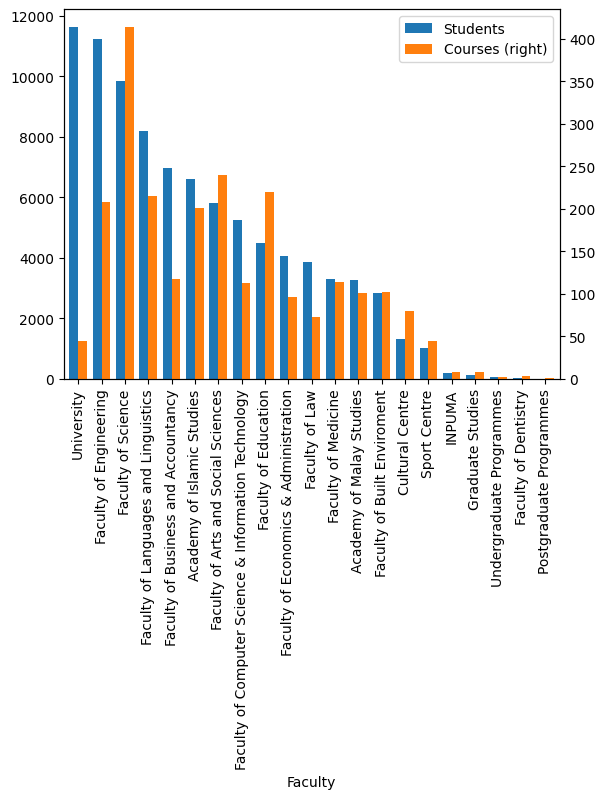

In [41]:
a = student_grade_detailed[['courseid','faculty']]
a = a.drop_duplicates(subset=['courseid'])
a = a['faculty'].value_counts()

b = student_grade_detailed['faculty'].value_counts()

c = pd.merge(b,a,left_index=True,right_index=True)
c = c.rename(columns={'count_x':"Students","count_y":"Courses"})

ax = c.plot(kind='bar', secondary_y='Courses', width=0.75, align='center')
ax.set_xlabel('Faculty')
plt.xticks(rotation=45, ha='right')
ax.get_tightbbox() #OK

# Student_grade_aggregated

In [18]:

student_grade_aggregated = pd.read_csv(f"{path}Student_grade_aggregated.csv")
from ydata_profiling import ProfileReport

profile = ProfileReport(student_grade_aggregated,title='Test')
profile

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  1.78it/s]


## Verify figure

Bbox([[5.097222222222218, -20.902777777777786], [450.0, 264.0]])

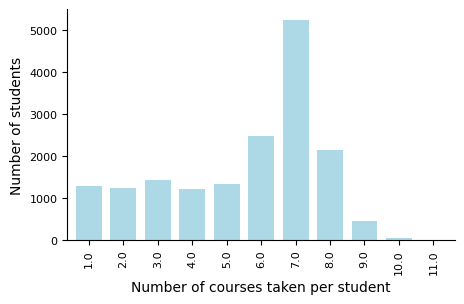

In [89]:
ax =student_grade_aggregated['number_of_courses'].value_counts().sort_index().plot(kind='bar',logy=False,fontsize=8, figsize=(5,3),color='lightblue',
                                                                          width=0.75,align='center')

ax.set_title("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Number of courses taken per student')
ax.set_ylabel('Number of students')
    
yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 5)
yticklabels = yticks
    
ax.get_tightbbox()#OK


# Student_activity_summary

In [100]:
Student_activity_summary = pd.read_csv(f"{path}Student_actvitiy_summary.csv")

(16909, 20)


,userid,number_of_courses,average_marks,average_login,weekend_login,weekday_login,midnight_login,early_morning_login,late_morning_login,afternoon_login,evening_login,night_login,no_of_viewed_courses,no_of_attendance_taken,no_of_all_files_downloaded,no_of_assignments,no_of_forum_created,number_of_quizzes,no_of_quizzes_completed,no_of_quizzes_attempt
0,64.0,6.0,60.483333,28.000000,4.000000,24.000000,7.166667,5.500000,5.333333,6.833333,1.666667,1.500000,213.666667,0.333333,0.166667,2.666667,0.000000,2.833333,0.666667,1.333333
1,65.0,6.0,53.650000,14.666667,0.833333,13.833333,4.833333,2.500000,2.333333,4.166667,0.333333,0.500000,40.166667,0.166667,0.166667,1.833333,0.000000,1.500000,0.833333,1.833333
2,66.0,7.0,67.514286,21.000000,3.428571,17.571429,9.000000,4.428571,1.714286,5.428571,0.142857,0.285714,215.428571,0.000000,0.000000,4.142857,0.285714,0.428571,0.142857,0.142857


## Verify figure QQplot

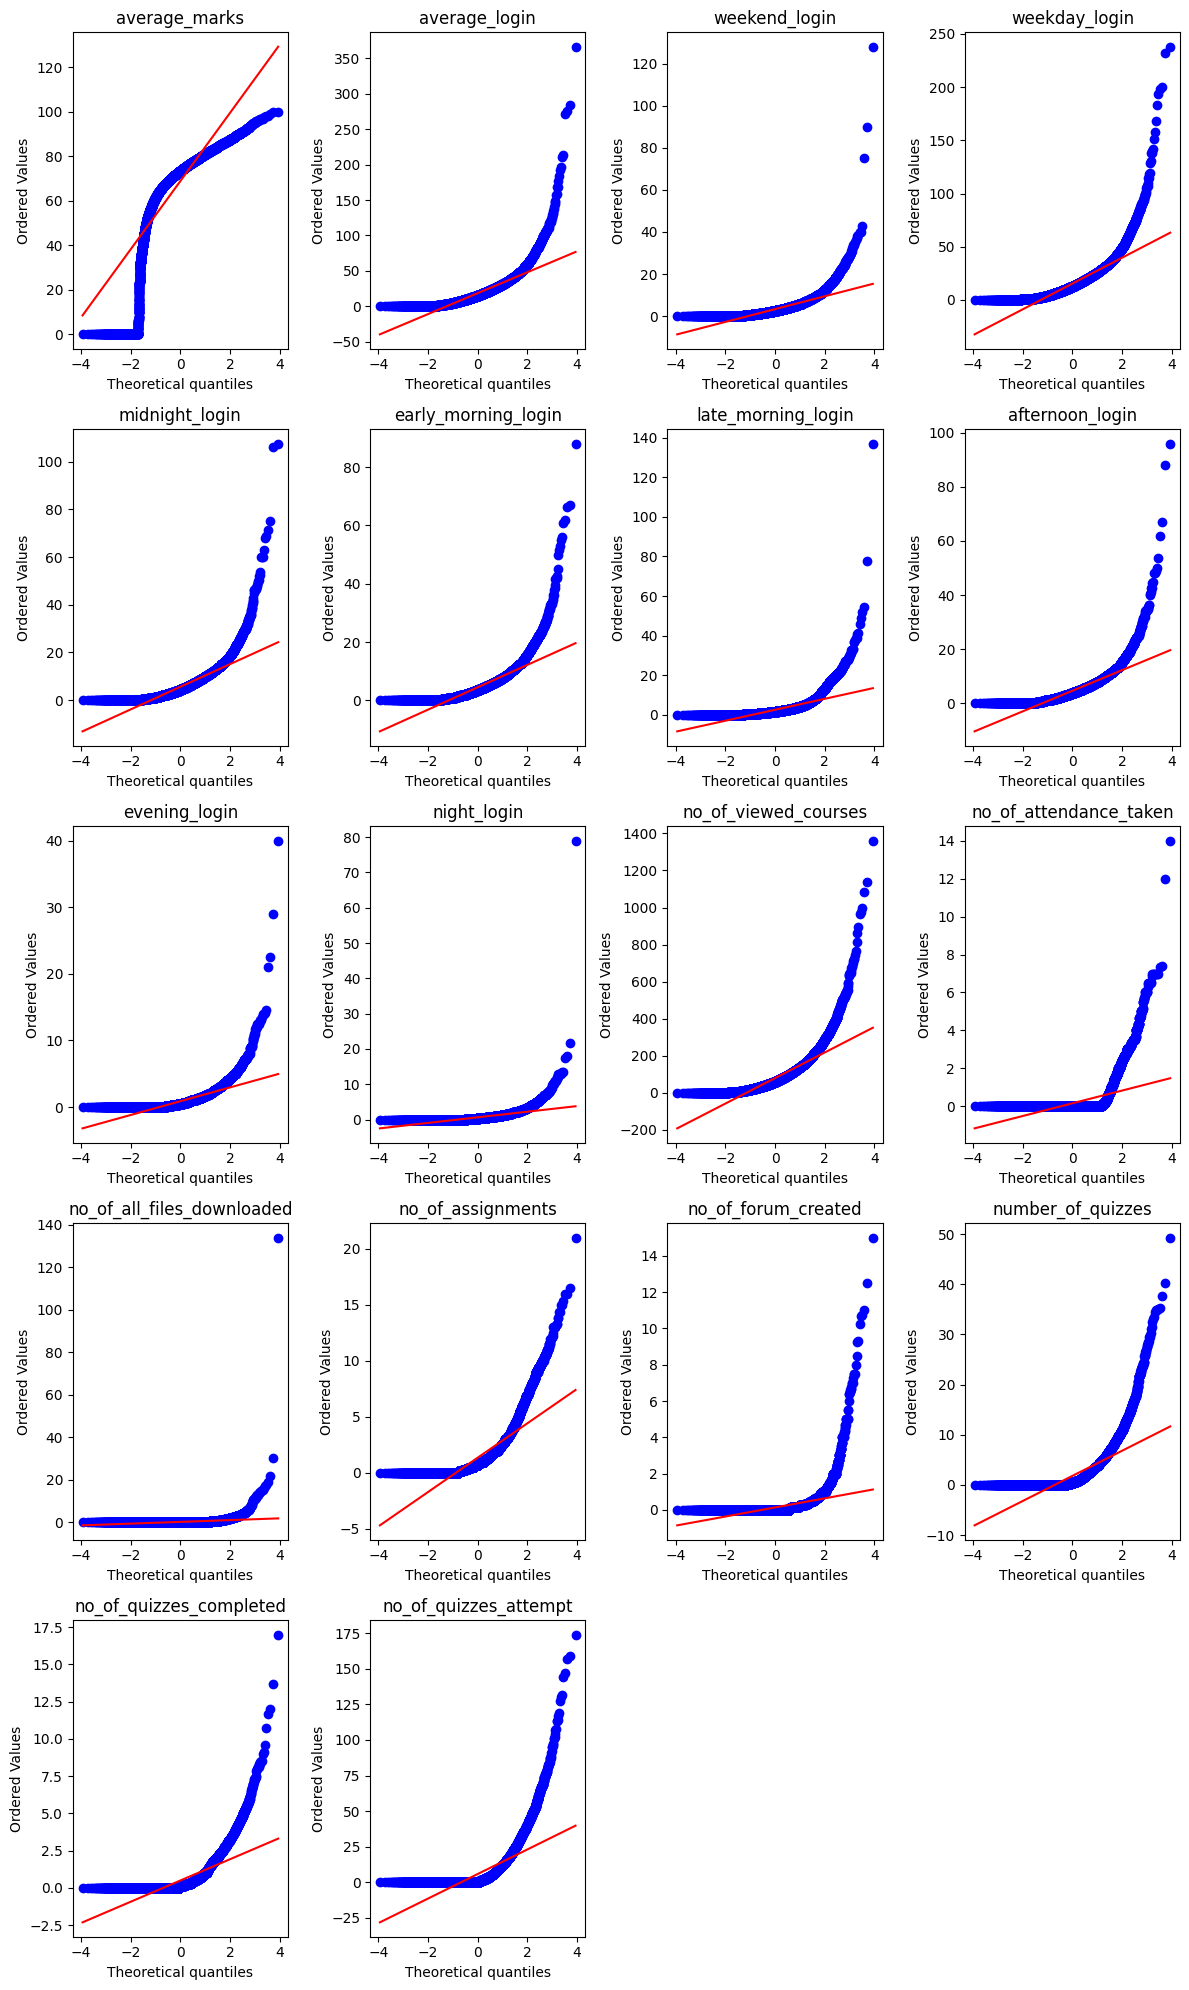

In [104]:
import scipy.stats as stats

SummaryStatsdf = Student_activity_summary.loc[:,Student_activity_summary.columns != 'userid']

qq_df = SummaryStatsdf.iloc[:,SummaryStatsdf.columns!='number_of_courses']
qq_df = qq_df.iloc[:,qq_df.columns!='f_quizzes_giveup']

qq_df.rename(columns={'total_marks':'average_marks'},inplace=True)

num_columns = len(qq_df.columns)
cols = 4  # Number of columns in the grid
rows = (num_columns + cols - 1) // cols  # Calculate rows needed

# Create subplots
fig, axs = plt.subplots(rows, cols, figsize=(12, rows * 4))
axs = axs.flatten()  # Flatten in case of a grid

for i, column in enumerate(qq_df.columns):
    stats.probplot(qq_df[column], dist="norm", plot=axs[i])
    axs[i].set_title(f'{column}')

# Hide any unused subplots if the number of columns is not even
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()
#OK


## Verify figure boxplot 

Bbox([[32.97222222222221, -85.91360070985205], [576.0379376378077, 422.4]])

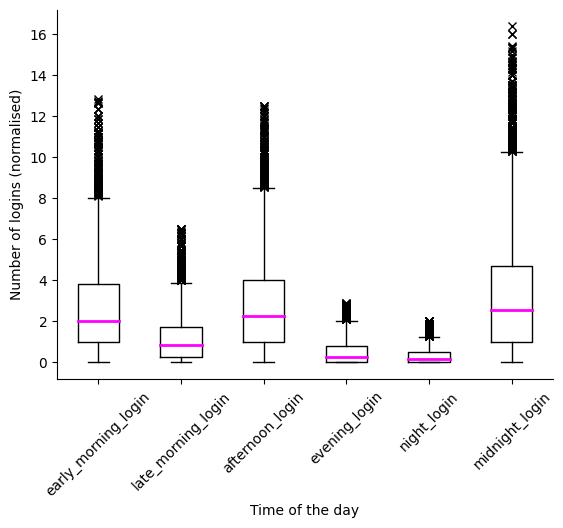

In [106]:
# Define a function to remove outliers using the IQR method
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Remove outliers
boxdf = Student_activity_summary.loc[:,Student_activity_summary.columns != 'userid']
df_no_outliers = remove_outliers_iqr(boxdf)

time_df = df_no_outliers[['average_login','early_morning_login','late_morning_login','afternoon_login','evening_login','night_login','midnight_login','weekend_login','weekday_login',]]

day_df = time_df[['early_morning_login','late_morning_login','afternoon_login','evening_login','night_login','midnight_login']]
ax = day_df.boxplot(medianprops = {'color': "magenta", 'linewidth': 2},
                boxprops = {'color': 'black', 'linestyle': '-'},
                whiskerprops = {'color': 'black', 'linestyle': '-'},
                capprops = {'color': 'black', 'linestyle': '-'},
                flierprops = {'color': 'black', 'marker': 'x'},
                grid = False
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Time of the day')
ax.set_ylabel('Number of logins (normalised)')
plt.yticks(np.arange(0, 18, 2))
plt.xticks(rotation=45)
ax.get_tightbbox()

#Ok